# Escalado
Conjunto de datos: iris (incluido en sklearn)
Este conjunto de datos es compacto y perfecto para demostrar técnicas de escalado.

In [1]:
# Importar librerías necesarias
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Cargar el conjunto de datos
iris = load_iris(as_frame=True)
data = iris.data

In [3]:
# Visualizar las estadísticas iniciales
print("Estadísticas iniciales:")
data.describe()

Estadísticas iniciales:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
# Aplicar MinMaxScaler
minmax_scaler = MinMaxScaler()
data_minmax = pd.DataFrame(minmax_scaler.fit_transform(data), columns=data.columns)

In [5]:
# Aplicar StandardScaler
standard_scaler = StandardScaler()
data_standard = pd.DataFrame(standard_scaler.fit_transform(data), columns=data.columns)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre las estadísticas originales y las del escalado MinMax?


In [6]:
# Comparar estadísticas originales vs MinMaxScaler
print("Estadísticas originales:")
print(data.describe())

print("\nEstadísticas tras MinMaxScaler:")
print(data_minmax.describe())

# Diferencias clave: tras MinMax todas las columnas tienen min=0 y max=1
print("\nDiferencias en min/max:")
diff = pd.DataFrame({
    'min_original': data.min(),
    'min_minmax': data_minmax.min(),
    'max_original': data.max(),
    'max_minmax': data_minmax.max()
})
print(diff)

# Respuesta:
# - El MinMaxScaler reescala cada variable al rango [0, 1].
# - Los valores mínimo y máximo de cada columna pasan a ser exactamente 0 y 1.
# - La forma de la distribución se conserva (no cambia la asimetría ni la dispersión relativa),
#   solo cambian la escala y las unidades.
# - La media y la desviación estándar dejan de tener su valor original y se reescalan también.

Estadísticas originales:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  

Estadísticas tras MinMaxScaler:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.00

### 2. Crea una gráfica de la distribución de la variable 'sepal length (cm)' antes y después del escalado.

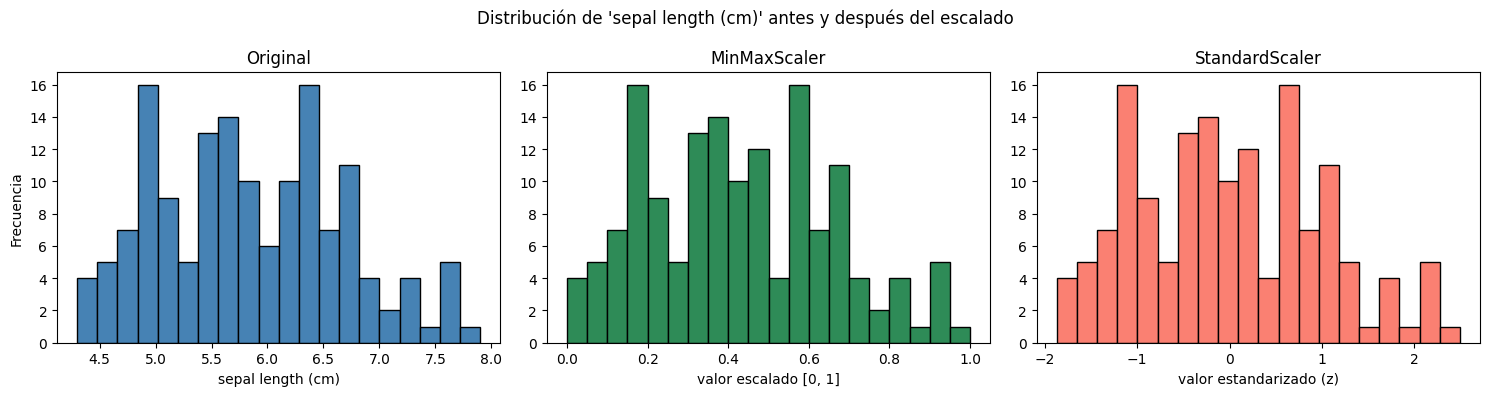

In [7]:
# Distribución de 'sepal length (cm)' antes y después del escalado
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(data['sepal length (cm)'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Original')
axes[0].set_xlabel('sepal length (cm)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(data_minmax['sepal length (cm)'], bins=20, color='seagreen', edgecolor='black')
axes[1].set_title('MinMaxScaler')
axes[1].set_xlabel('valor escalado [0, 1]')

axes[2].hist(data_standard['sepal length (cm)'], bins=20, color='salmon', edgecolor='black')
axes[2].set_title('StandardScaler')
axes[2].set_xlabel('valor estandarizado (z)')

plt.suptitle("Distribución de 'sepal length (cm)' antes y después del escalado")
plt.tight_layout()
plt.show()

### 3. Crea una gráfica de dispersión entre 'sepal length (cm)' y 'sepal width (cm)' con los datos escalados por StandardScaler.

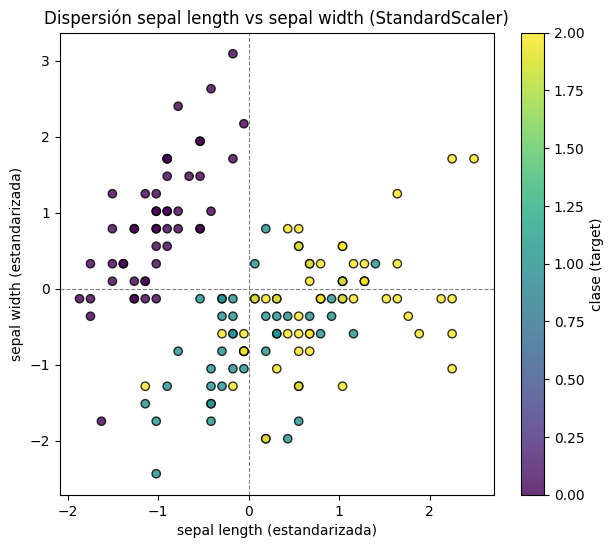

In [8]:
# Gráfica de dispersión de sepal length vs sepal width (StandardScaler)
plt.figure(figsize=(7, 6))
plt.scatter(
    data_standard['sepal length (cm)'],
    data_standard['sepal width (cm)'],
    c=iris.target,
    cmap='viridis',
    edgecolor='black',
    alpha=0.8
)
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.axvline(0, color='gray', linewidth=0.8, linestyle='--')
plt.xlabel('sepal length (estandarizada)')
plt.ylabel('sepal width (estandarizada)')
plt.title('Dispersión sepal length vs sepal width (StandardScaler)')
plt.colorbar(label='clase (target)')
plt.show()

### 4. ¿Qué técnica de escalado crees que es más adecuada para este conjunto de datos? ¿Por qué?

**Respuesta:**

Para el conjunto **iris**, el **StandardScaler** suele ser la opción más adecuada por las siguientes razones:

- Las variables (largo y ancho de sépalos y pétalos) tienen distribuciones aproximadamente simétricas, cercanas a una normal. `StandardScaler` (media 0, desviación 1) funciona muy bien en ese caso.
- Muchos algoritmos populares (regresión logística, SVM, KNN, PCA, redes neuronales) suponen o se benefician de variables centradas en 0 y con varianza similar.
- No hay un rango fijo conocido y deseado [0, 1] para estas variables, por lo que la normalización MinMax no aporta una ventaja particular.

`MinMaxScaler` sería preferible cuando:
- Se necesita un rango acotado [0, 1] (p. ej., entradas de redes neuronales con activaciones sigmoides, o píxeles de imágenes).
- Las distribuciones son muy sesgadas o no normales y queremos preservar relaciones de proporción.

En presencia de outliers fuertes, ninguna de las dos es ideal y se preferiría `RobustScaler`.